In [5]:
# 1. Imports y carga del dataset.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, accuracy_score, mean_absolute_percentage_error, max_error, make_scorer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif, VarianceThreshold
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import re
from matplotlib.ticker import PercentFormatter



from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [6]:
#2. Carga del dataset.
df_train = pd.read_csv("Data/train.csv")
df_test = pd.read_csv("Data/test.csv")


In [19]:
#Funciones auxiliares
def get_top_correlations(corr_matrix):
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    corr_pairs = upper_triangle.stack().reset_index()
    corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    sorted_pairs = corr_pairs.assign(abs_corr=corr_pairs['Correlation'].abs()) \
                             .sort_values(by='abs_corr', ascending=False) \
                             .drop(columns=['abs_corr'])

    return sorted_pairs.reset_index(drop=True)

def num_correlation_classifier(df, target, threshold=0.0, sort_by_abs=True):
    corr = df.corr(numeric_only=True)[target].drop(target)
    corr_df = (
        corr.reset_index()
        .rename(columns={"index": "feature", target: "correlation"})
    )
    corr_df["direction"] = corr_df["correlation"].apply(
        lambda x: "positive" if x > 0 else "negative"
    )
    def classify_strength(c):
        c = abs(c)
        if c < 0.1:
            return "very weak"
        elif c < 0.3:
            return "weak"
        elif c < 0.5:
            return "moderate"
        elif c < 0.7:
            return "strong"
        else:
            return "very strong"
    corr_df["strength"] = corr_df["correlation"].apply(classify_strength)
    corr_df["abs_correlation"] = corr_df["correlation"].abs()
    corr_df = corr_df[corr_df["abs_correlation"] >= threshold]
    if sort_by_abs:
        corr_df = corr_df.sort_values("abs_correlation", ascending=False)
    else:
        corr_df = corr_df.sort_values("correlation", ascending=False)
    corr_df = corr_df.reset_index(drop=True)
    return corr_df


def num_analysis(df, target):
    corr = df.corr(numeric_only=True)
    if target in corr.columns:
        corr_y = corr[target].drop(target).sort_values()
        plt.figure(figsize=(10,10))
        corr_y.plot(kind='barh')
        plt.title(f'Correlation with {target}')
        plt.xlabel('Correlation')
        plt.ylabel('Features')
        plt.show()


def get_top_correlations(corr_matrix):
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    corr_pairs = upper_triangle.stack().reset_index()
    corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    sorted_pairs = corr_pairs.assign(abs_corr=corr_pairs['Correlation'].abs()) \
                             .sort_values(by='abs_corr', ascending=False) \
                             .drop(columns=['abs_corr'])

    return sorted_pairs.reset_index(drop=True)

def drop_features(X):
    X = X.drop(columns=unused_features, errors='ignore')
    return X


drop_features_transformer = FunctionTransformer(drop_features).set_output(transform="pandas")


In [9]:
#3 Se revisan tipo de variblaes y cantidad de nulos
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   str    
 1   Basic_Demos-Enroll_Season               3960 non-null   str    
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   str    
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   str    
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight                         3076 non-null   float64
 10  Physical-Waist_Circumference            898 non-null    float64
 11  Ph

In [10]:
#4 Se revisa cantidad de nulos en variable objetivo y destribución de clases
print(df_train["sii"].isnull().value_counts(normalize=True))
print(df_train["sii"].value_counts(normalize=True))

sii
False    0.690909
True     0.309091
Name: proportion, dtype: float64
sii
0.0    0.582602
1.0    0.266813
2.0    0.138158
3.0    0.012427
Name: proportion, dtype: float64


In [11]:
#5 Se eliminan filas con nulos en variable objetivo para hacer entrenamiento supervisado
df_train = df_train[df_train["sii"].notnull()]
df_train.shape

(2736, 82)

                                    Column     Empty  Not_Empty
51                       PAQ_A-PAQ_A_Total  0.867325   0.132675
50                            PAQ_A-Season  0.867325   0.132675
10            Physical-Waist_Circumference  0.823465   0.176535
17              Fitness_Endurance-Time_Sec  0.733918   0.266082
16             Fitness_Endurance-Time_Mins  0.733918   0.266082
15             Fitness_Endurance-Max_Stage  0.732822   0.267178
24                        FGC-FGC_GSD_Zone  0.684211   0.315789
22                       FGC-FGC_GSND_Zone  0.684211   0.315789
23                             FGC-FGC_GSD  0.681652   0.318348
21                            FGC-FGC_GSND  0.681287   0.318713
14                Fitness_Endurance-Season  0.539474   0.460526
52                            PAQ_C-Season  0.473684   0.526316
53                       PAQ_C-PAQ_C_Total  0.473684   0.526316
42                             BIA-BIA_FMI  0.337354   0.662646
38                             BIA-BIA_D

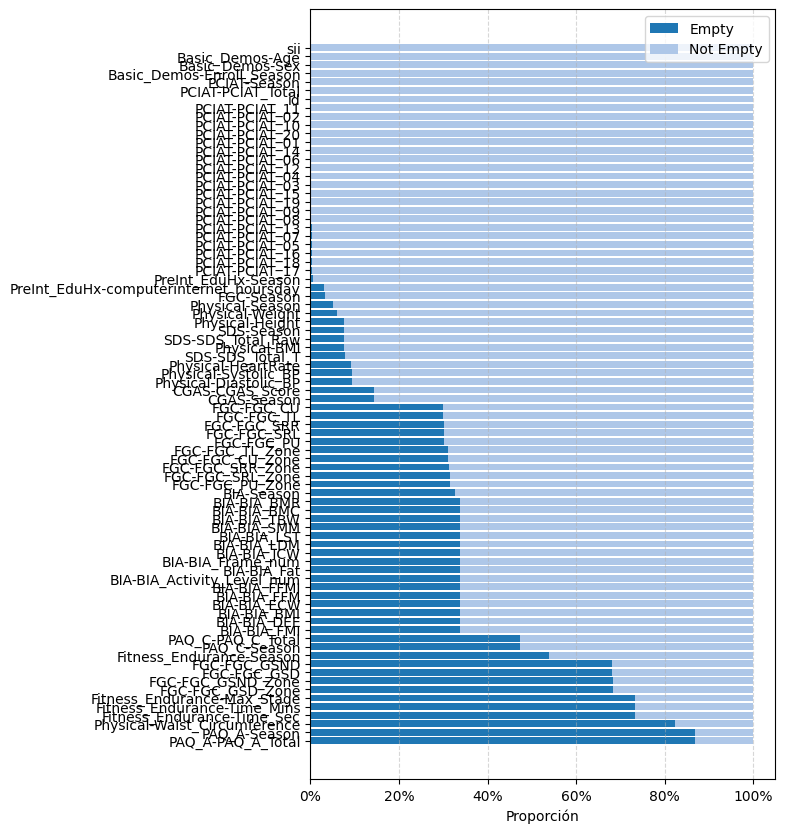

In [12]:
#6 Se revisa cantidad de nulos en cada variable con respecto de la vairable objetivo
empty = []

# A. Se calcula la proporción de valores nulos y no nulos para cada columna
for column in df_train.columns:
    empty.append((column, df_train[column].isnull().mean(), df_train[column].notnull().mean()))

# B. Se crea un DataFrame para visualizar los resultados
empty_df = pd.DataFrame(empty, columns=["Column", "Empty", "Not_Empty"])
empty_df = empty_df.sort_values(by="Empty", ascending=False)
print(empty_df.to_string())

# Se visualiza la proporción de valores nulos y no nulos para cada columna
missing_color = '#1f77b4'
available_color = '#aec7e8'

plt.figure(figsize=(6, 10))
y_pos = np.arange(len(empty_df))

plt.barh(y_pos, empty_df["Empty"], label="Empty", color=missing_color)
plt.barh(y_pos, empty_df["Not_Empty"], left=empty_df["Empty"], label="Not Empty", color=available_color)
plt.yticks(y_pos, empty_df["Column"])
plt.xlabel("Proporción")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend()


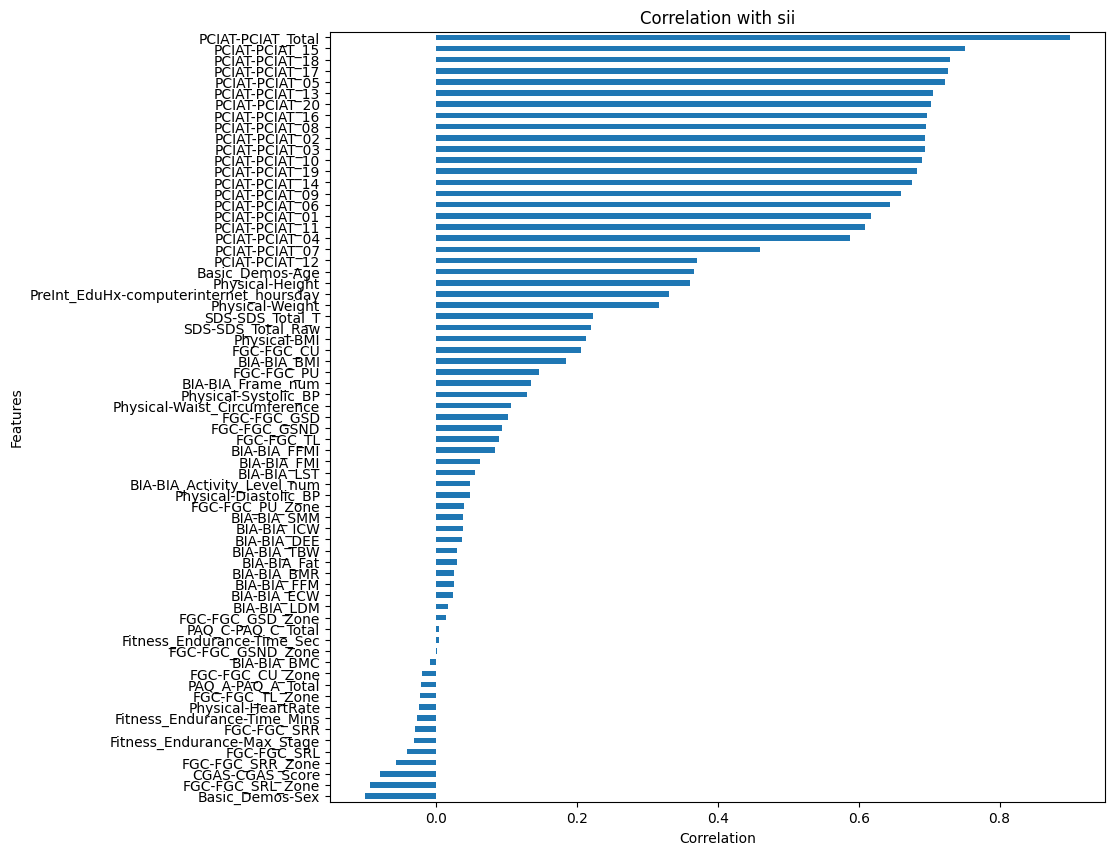

,feature,correlation,direction,strength,abs_correlation
0,PCIAT-PCIAT_Total,0.899681,positive,very strong,0.899681
1,PCIAT-PCIAT_15,0.750544,positive,very strong,0.750544
2,PCIAT-PCIAT_18,0.730237,positive,very strong,0.730237
3,PCIAT-PCIAT_17,0.726351,positive,very strong,0.726351
4,PCIAT-PCIAT_05,0.721932,positive,very strong,0.721932
5,PCIAT-PCIAT_13,0.704838,positive,very strong,0.704838
6,PCIAT-PCIAT_20,0.702466,positive,very strong,0.702466
7,PCIAT-PCIAT_16,0.697696,positive,strong,0.697696
8,PCIAT-PCIAT_08,0.695094,positive,strong,0.695094
9,PCIAT-PCIAT_02,0.694453,positive,strong,0.694453


In [13]:
df_num = df_train.select_dtypes(include=np.number)
df_num = df_num.fillna(df_num.mean())
df_eda = df_num.loc[:, df_num.nunique() > 1]
corr = df_eda.corr()
target = "sii"
num_analysis(df_eda, target)
corr_table = num_correlation_classifier(
    df_eda,
    target,
    threshold=0.0
)
with pd.option_context(
    'display.max_rows', None,
    'display.expand_frame_repr', False
):
    display(corr_table)

In [14]:
df_train.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

In [17]:
df_num = df_train.select_dtypes(include=np.number)
df_num = df_num.fillna(df_num.mean())
df_eda = df_num.loc[:, df_num.nunique() > 1]
corr_matrix = df_eda.corr()

corr_matrix_eda = df_eda.select_dtypes(include=[np.number]).corr()
top_corrs = get_top_correlations(corr_matrix_eda)
strong_corrs = top_corrs[top_corrs['Correlation'].abs() > 0.5]
with pd.option_context('display.max_rows', None, 'display.expand_frame_repr', False):
    display(strong_corrs)

,Feature 1,Feature 2,Correlation
0,BIA-BIA_BMR,BIA-BIA_FFM,1.000000
1,BIA-BIA_BMR,BIA-BIA_TBW,0.999652
2,BIA-BIA_FFM,BIA-BIA_TBW,0.999652
3,BIA-BIA_ECW,BIA-BIA_FFM,0.999182
4,BIA-BIA_BMR,BIA-BIA_ECW,0.999182
5,BIA-BIA_ECW,BIA-BIA_TBW,0.999021
6,BIA-BIA_FFM,BIA-BIA_LDM,0.998821
7,BIA-BIA_BMR,BIA-BIA_LDM,0.998821
8,BIA-BIA_ICW,BIA-BIA_TBW,0.998337
9,BIA-BIA_ECW,BIA-BIA_LDM,0.997658


In [21]:
# 5. Clasificación de features (SII).
unused_features = [
    # indicadores derivados
    'PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 
    'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 
    'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 
    'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 
    'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 
    'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 
    'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 
    'PCIAT-PCIAT_Total',


    # Variables con demasiados nulos
    'PAQ_A-Season',
    'PAQ_A-PAQ_A_Total',
    'Physical-Waist_Circumference',
    'Fitness_Endurance-Time_Sec',
    'Fitness_Endurance-Time_Mins',
    'Fitness_Endurance-Max_Stage',

    # identificadores
    'id',
]
#---------------------------------------------------------------------------------------------------------
derivation_features = [
    {
        'new_col': 'balance_hidrico_ciclo',
        'cols': ['lluvias_ciclo', 'm3_riego'],
        'op': 'sum',
        'impute': 'mean'
    },
    {
        'new_col': 'indice_vigor',
        'cols': ['edad_precosecha', 'vejez'],
        'op': 'div',
        'impute': 'median'
    }
]

#---------------------------------------------------------------------------------------------------------
num_no_imputation = [



]
num_mean = [
 'Basic_Demos-Age', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 
 'Physical-Weight', 'Physical-HeartRate', 'Physical-Diastolic_BP', 
 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 
 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_BMC', 
 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 
 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_ICW', 'BIA-BIA_LST', 
 'BIA-BIA_LDM', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_C-PAQ_C_Total', 'SDS-SDS_Total_Raw', 
 'SDS-SDS_Total_T'
]
num_median = [

]
num_zero = [


]
numeric_features = num_no_imputation + num_mean + num_median + num_zero
#---------------------------------------------------------------------------------------------------------
cat_no_imputation = [

]
cat_mode = [
 'Basic_Demos-Enroll_Season', 'Basic_Demos-Sex', 'CGAS-Season', 
 'Physical-Season', 'FGC-Season', 'Fitness_Endurance-Season', 'BIA-Season', 
 'PAQ_C-Season', 'PreInt_EduHx-Season', 'SDS-Season'
]
cat_unknown = [
'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone', 
'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 
'FGC-FGC_TL_Zone', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
 'PreInt_EduHx-computerinternet_hoursday'
]
categorical_features = cat_no_imputation + cat_mode + cat_unknown

used_features = numeric_features + categorical_features

In [ ]:
# 6. Definición de Pipelines de Imputación, Escalado y Encoding.
# a. Pipeline de limpieza.
dataset_cleaning_pipeline = Pipeline(steps=[
    ("drop_unused", drop_features_transformer)
])
# b. Pipeline numérico.
num_imputer = ColumnTransformer(transformers=[
    ("mean", SimpleImputer(strategy="mean"), num_mean)
], remainder='passthrough')

numeric_pipeline = Pipeline(steps=[
    ("imputer", num_imputer),
    ("scaler", StandardScaler())
], )
# c. Pipeline categórico.
cat_imputer = ColumnTransformer(transformers=[
    ("mode", SimpleImputer(strategy="most_frequent"), cat_mode),
    ("unknown", SimpleImputer(strategy="constant", fill_value="Unknown"), cat_unknown),
], remainder='passthrough')

categorical_pipeline = Pipeline(steps=[
    ("imputer", cat_imputer),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
# d. Preprocessor: Une ambos bloques de variables.
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])
# e. Process PipeLine: une el pipeline de limpieza inicial con preprocessor.
process_pipeline = Pipeline(steps=[
    ("clean", dataset_cleaning_pipeline),
    ("preprocessor", preprocessor)
])
# f. Implementación del Pipeline.
df_processed = process_pipeline.fit_transform(df_train)
df_processed = pd.DataFrame(
    df_processed,
    columns=preprocessor.get_feature_names_out()
    )
process_pipeline

ValueError: fill_value='Unknown' (of type <class 'str'>) cannot be cast to the input data that is dtype('float64'). If fill_value is a Python scalar, instead pass  a numpy scalar (e.g. fill_value=np.uint8(0) if your data is of type np.uint8). Make sure that both dtypes are of the same kind.